<h1 dir=rtl align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه کراس‌
</font>
</h1>

In [1]:
import keras
print(keras.__version__)

2.15.0


In [2]:
# If you are using a version of Keras lower than 3, you will need to uncomment the following line.
# !pip install keras --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.1/999.1 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.0.1 which is incompatible.


In [1]:
import keras
print(keras.__version__)

3.0.1


<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بک‌اند کراس
</font>
</h2>

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مجموعه‌داده
</font>
</h2>

In [3]:
# Load the data and split it between train and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مصورسازی
</font>
</h3>

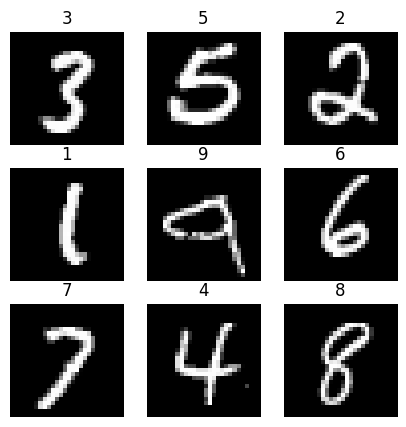

In [5]:
import random
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(5, 5))
cols = 3
rows = 3
for i in range(1, cols * rows + 1):
  sample_idx = random.randint(0, len(X_train))
  image = X_train[sample_idx]
  label = y_train[sample_idx]
  figure.add_subplot(rows, cols, i)
  plt.title(label)
  plt.axis('off')
  plt.imshow(image.squeeze(), cmap='gray')
plt.show()

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
نرمال‌سازی
</font>
</h3>

In [6]:
# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بارگیری داده‌ها با <code>DataLoader</code> پای‌تورچ
</font>
</h3>

In [9]:
import torch

BATCH_SIZE = 128

# Create a TensorDataset
train_torch_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_train)
)
val_torch_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(X_test), torch.from_numpy(y_test)
)

# Create a DataLoader
train_dataloader = torch.utils.data.DataLoader(
    train_torch_dataset, batch_size=BATCH_SIZE, shuffle=True
)
val_dataloader = torch.utils.data.DataLoader(
    val_torch_dataset, batch_size=BATCH_SIZE, shuffle=False
)

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بارگیری داده‌ها با <code>tf.data</code> تنسورفلو
</font>
</h3>

In [10]:
import tensorflow as tf

BATCH_SIZE = 128

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
تبدیل برچسب
</font>
</h3>

In [11]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [12]:
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [13]:
y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])